In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Social_Network_Ads.csv')

In [4]:
dff=df.iloc[:,2:]
dff

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [5]:
from sklearn.model_selection import train_test_split


In [6]:
x_train,x_test,y_train,y_test=train_test_split(dff.drop('Purchased', axis=1),dff['Purchased'],test_size=0.3,random_state=0)
#test split mean how many data you want to split from your data total in 1 so 0.3 is 30% and rando_state mean picking of value so every time no random packing just b/c random_state=0,so 0 random 

In [7]:
x_train.shape,x_test.shape

((280, 2), (120, 2))

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)   # fit funtion is used for learning so x_train will be learn and train
x_trainScaled=scaler.transform(x_train)
x_testScaled=scaler.transform(x_test)  # remember this that we learn or tain only oe data but they wil transfor to both everyntime

In [9]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [10]:
# scaled funtion have issue they convrt the dataframe of pandas to numpy array so firt we conver the array to dataframe of both
x_tainScaled=pd.DataFrame(x_trainScaled,columns=x_train.columns)
x_testScaled=pd.DataFrame(x_testScaled,columns=x_test.columns)
np.round(x_train.describe(),1)


,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [11]:
x_tainScaled    # now see all value of the age is trasnform

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [12]:
np.round(x_train.describe(),1)    # see the mean before feature scaling data set 
                                   # SD before

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [13]:
np.round(x_tainScaled.describe(),1)   # 1 reperesent number of deimal places 
                                      # now see mean is 0 according to feature scaling median will be 0 after scling process
                                       # sd after

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


Text(0.5, 1.0, 'after scaling')

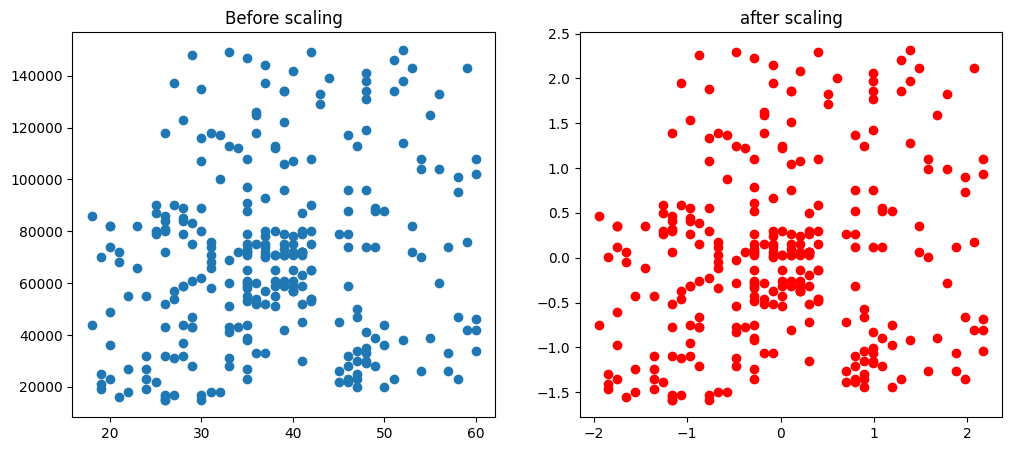

In [14]:
# through ploting
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('Before scaling')
ax2.scatter(x_tainScaled['Age'],x_tainScaled['EstimatedSalary'],color='red')
ax2.set_title('after scaling')
# if we see the both plots the points are same but if we see axes of plot value of age and salery you will see the diff 
# they decrease the values if see

Text(0.5, 1.0, 'after scaling')

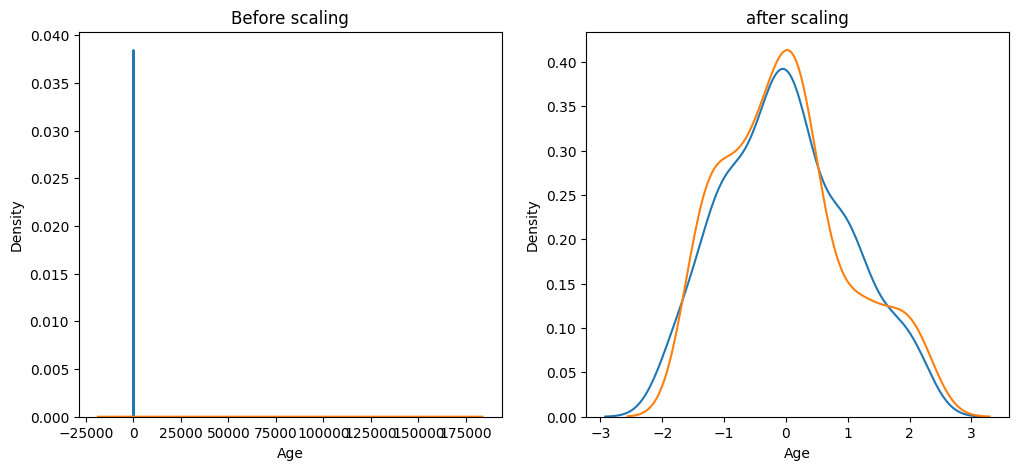

In [15]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)            
ax1.set_title('Before scaling')

sns.kdeplot(x_tainScaled['Age'],ax=ax2)
sns.kdeplot(x_tainScaled['EstimatedSalary'],ax=ax2)
ax2.set_title('after scaling')


# so if we see now before scaling there is no comparison in values like age is smal and salery is very large value so for his reason 
# and after we appling sacling and vlue now have comparison so now see the pot

In [23]:
# why sacling is important 


In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
ts=LogisticRegression()
ts_scaled=LogisticRegression()

In [36]:
ts.fit(x_train,y_train)
ts_scaled.fit(x_tainScaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred=ts.predict(x_test)
y_pred_scaled=ts_scaled.predict(x_testScaled)

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
print("actual:",accuracy_score(y_test,y_pred))
print("scaled:",accuracy_score(y_test,y_pred_scaled))

actual: 0.875
scaled: 0.8666666666666667
